<a href="https://colab.research.google.com/github/VaneCamposGuzman/Caries/blob/main/Entrenamiento_Caries_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install ultralytics

In [34]:
import zipfile

# Ya corregido con la T mayúscula y el espacio exacto
ruta_zip_local = '/content/tooth cavities.v1i.yolov8.zip'
ruta_destino = '/content/dataset_caries'

# Con esto abrimos el archivo de forma segura sin importar los espacios
with open(ruta_zip_local, 'rb') as f:
    with zipfile.ZipFile(f, 'r') as zip_ref:
        zip_ref.extractall(ruta_destino)

print("¡LOGRADO! Dataset listo para entrenar.")
print(os.listdir(ruta_destino))


¡LOGRADO! Dataset listo para entrenar.
['test', 'train', 'valid', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml']


In [36]:
from ultralytics import YOLO

# 1. Cargamos el modelo YOLOv8 Nano (es el más rápido y ligero)
model = YOLO("yolov8n.pt")

# 2. Arrancamos el entrenamiento apuntando al data.yaml que acabas de descomprimir
results = model.train(
    data="/content/dataset_caries/data.yaml",  # Ruta al archivo de la lista
    epochs=25,                                 # 25 pocas
    imgsz=640,                                 # Tamaño de imagen estandar de YOLO
    device=0                                   # Fuerza a usar la tarjeta gráfica T4 activa
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_caries/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1


image 1/1 /content/prueba.jpg: 288x640 3 1s, 42.8ms
Speed: 2.0ms preprocess, 42.8ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 640)


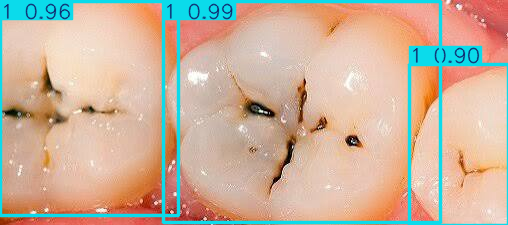

In [37]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Cargamos TU modelo ya entrenado (el que está en train-2)
model_entrenado = YOLO("/content/runs/detect/train-2/weights/best.pt")

# 2. Hacemos la predicción sobre la imagen que subiste
# (Cambia 'prueba_caries.jpg' por el nombre real de tu archivo)
resultados = model_entrenado.predict(source="/content/prueba.jpg", conf=0.5)

# 3. Mostramos el resultado con los cuadros delimitadores en pantalla
for r in resultados:
    im_bgr = r.plot()  # Dibuja los cuadros de las caries detectadas
    cv2_imshow(im_bgr) # Muestra la imagen final aquí en Colab